# Model database fetching and inference

## Load model & set up genome

In [1]:
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
matplotlib.rcParams["pdf.fonttype"] = 42  
matplotlib.rcParams["ps.fonttype"] = 42 

In [2]:
from pathlib import Path
import numpy as np
import keras
import crested
from helper_functions import *

2025-07-11 12:20:05.730136: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-11 12:20:05.744532: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752261605.760215 2220858 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752261605.764862 2220858 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-11 12:20:05.780969: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [3]:
model_path, output_names_biccn = crested.get_model("DeepBICCN2")
model_biccn = keras.models.load_model(model_path, compile=False)

I0000 00:00:1752261635.634386 2220858 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38485 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:ca:00.0, compute capability: 8.0


In [4]:
model_path, output_names_wmb = crested.get_model("DeepMouseBrain3")
model_wmb = keras.models.load_model(model_path, compile=False)

In [5]:
model_path = "/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/OCTO/aibs-octo-dnaseq-modeling/spinal_cord/data/human/analysis/spc_human/ft/checkpoints/06.keras"
human_model = keras.models.load_model(model_path, compile=False) 

#model_path = "/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/OCTO/aibs-octo-dnaseq-modeling/spinal_cord/data/macaque/analysis/spc_macaque/ft2/checkpoints/14.keras"
model_path = "/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/OCTO/aibs-octo-dnaseq-modeling/spinal_cord/data/macaque/analysis/spc_macaque/ft3/checkpoints/05.keras"
macaque_model = keras.models.load_model(model_path, compile=False)  

#model_path = "/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/OCTO/aibs-octo-dnaseq-modeling/spinal_cord/data/mouse/analysis/spc_mouse/ft/checkpoints/16.keras"
model_path = "/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/OCTO/aibs-octo-dnaseq-modeling/spinal_cord/data/mouse/analysis/spc_mouse/ft2/checkpoints/24.keras"
mouse_model = keras.models.load_model(model_path, compile=False)  

In [6]:
import anndata as ad
adata_macaque = ad.read_h5ad("/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/OCTO/aibs-octo-dnaseq-modeling/spinal_cord/data/macaque/crested_adata/macaque_spinalcord_hmba_crested_chromsplit_norm_filtered2.h5ad")
output_names_macaque = list(adata_macaque.obs_names)
adata_human= ad.read_h5ad("/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/OCTO/aibs-octo-dnaseq-modeling/spinal_cord/data/human/crested_adata/human_spinalcord_hmba_crested_chromsplit_norm_filtered.h5ad")
output_names_human = list(adata_human.obs_names)
adata_mouse= ad.read_h5ad("/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/OCTO/aibs-octo-dnaseq-modeling/spinal_cord/data/mouse/crested_adata/mouse_spinalcord_hmba_crested_chromsplit_norm_filtered.h5ad")
output_names_mouse = list(adata_mouse.obs_names)

In [7]:
# Set the genome
genome_dir = Path("../../../../mouse/biccn/")
genome = crested.Genome("/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/OCTO/aibs-octo-dnaseq-modeling/genomes/mouse/fasta/mm10.fa", "/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/OCTO/aibs-octo-dnaseq-modeling/genomes/mouse/mm10.chrom.sizes")
crested.register_genome(genome)

2025-07-11T13:11:17.423552-0700 INFO Genome mm10 registered.


# Load all regions

In [8]:
import pandas as pd
df = pd.read_csv('/home/niklas.kempynck/nkemp/software/crested_notebooks/MN_list.csv')
df

,Signal,Primary Screening Data Collected? A representative image from cervical cord in-hand for supp figure? Expression?,Plasmid #,Vector Design,Enhancer ID,Cell Type target,Proximal Gene,Mouse Genome Coordinates,Rhesus Genome Coordinates
0,yes,Yes,HCT1,HCT1_pAAV-eHGT_1137m-minBGprom-SYFP2-WPRE3-bGHpA,eHGT_1137m,pan spinal motor neuron,ChAT,"chr14:32,468,473-32,469,163",NaN
1,yes,Yes,HCT2,HCT2_ pAAV-eHGT_1138m-minBGprom-SYFP2-WPRE3-bGHpA,eHGT_1138m,pan spinal motor neuron,ChAT,"chr14:32,265,147-32,265,998",NaN
2,yes,Yes,HCT6,HCT6_ pAAV-eHGT_1141m-minBGprom-SYFP2-WPRE3-bGHpA,eHGT_1141m,pan spinal motor neuron,Spp1,"chr5:104,239,701-104,240,770",NaN
3,ok,Yes,HCT7,HCT7_pAAV-eHGT_1142m-minBGprom-SYFP2-WPRE3-bGHpA,eHGT_1142m,pan spinal motor neuron,Spp1,"chr5:104,470,842-104,471,492",NaN
4,yes,Yes,HCT8,HCT8_ pAAV-eHGT_1143m-minBGprom-SYFP2-WPRE3-bGHpA,eHGT_1143m,pan spinal motor neuron,Esrrg,"chr1:187,052,314-187,053,069",NaN
5,yes,Yes,HCT9,HCT9_ pAAV-eHGT_1144m-minBGprom-SYFP2-WPRE3-bGHpA,eHGT_1144m,pan spinal motor neuron and CSF-cN,Esrrg,"chr1:187,052,266-187,053,125",NaN
6,no,Yes,HCT10,HCT10_ pAAV-eHGT_1145m-minBGprom-SYFP2-WPRE3-bGHpA,eHGT_1145m,pan spinal motor neuron,ChAT,"chr14:32,462,648-32,464,201",NaN
7,yes,Yes,HCT11,HCT11_ pAAV-eHGT_1048m-minBGprom-SYFP2-WPRE3-bGHpA,eHGT_1048m,pan spinal motor neuron,ChAT,chr14:32468423-32469127,NaN
8,yes,Yes,HCT12,HCT12_ pAAV-eHGT_1049m-minBGprom-SYFP2-WPRE3-bGHpA,eHGT_1049m,pan spinal motor neuron,Parg,"chr14:32,265,287-32,265,964",NaN
9,no,Yes,HCT13,HCT13_pAAV-eHGT_1050m-minBGprom-SYFP2-WPRE3-bGHpA,eHGT_1050m,pan spinal motor neuron,Chat,"chr14:32,467,171-32,468,049",NaN


In [9]:
import pandas as pd
import re
from pysam import FastaFile

def fetch_and_pad_sequence(coord_str, genome: FastaFile, target_length=2114):
    if pd.isna(coord_str):
        return None

    # Remove commas for parsing
    coord_str = coord_str.replace(",", "")
    
    # Extract coordinates
    match = re.match(r"(chr[\w\d]+):(\d+)-(\d+)", coord_str)
    if not match:
        return None
    
    chrom, start, end = match.groups()
    start = int(start)
    end = int(end)

    # Fetch only the sequence from start to end
    try:
        seq = genome.fetch(chrom, start, end).upper()
    except ValueError:
        seq = ""

    seq_len = len(seq)
    print(f"Fetched sequence length (non-N): {seq_len}")  # Debug print

    # Calculate padding
    total_pad = target_length - seq_len
    if total_pad < 0:
        raise ValueError(f"Target length {target_length} is shorter than genomic sequence length {seq_len}")

    left_pad = total_pad // 2
    right_pad = total_pad - left_pad

    padded_seq = "N" * left_pad + seq + "N" * right_pad
    return padded_seq

# Apply to DataFrame
df["sequence"] = df["Mouse Genome Coordinates"].apply(lambda x: fetch_and_pad_sequence(x, genome))

Fetched sequence length (non-N): 690
Fetched sequence length (non-N): 851
Fetched sequence length (non-N): 1069
Fetched sequence length (non-N): 650
Fetched sequence length (non-N): 755
Fetched sequence length (non-N): 859
Fetched sequence length (non-N): 1553
Fetched sequence length (non-N): 704
Fetched sequence length (non-N): 677
Fetched sequence length (non-N): 878
Fetched sequence length (non-N): 584
Fetched sequence length (non-N): 552
Fetched sequence length (non-N): 646
Fetched sequence length (non-N): 663
Fetched sequence length (non-N): 973
Fetched sequence length (non-N): 663
Fetched sequence length (non-N): 2063
Fetched sequence length (non-N): 764
Fetched sequence length (non-N): 828
Fetched sequence length (non-N): 710
Fetched sequence length (non-N): 1096
Fetched sequence length (non-N): 1012
Fetched sequence length (non-N): 626
Fetched sequence length (non-N): 1023
Fetched sequence length (non-N): 695
Fetched sequence length (non-N): 835
Fetched sequence length (non-N):

In [10]:
predictions = crested.tl.predict(df["sequence"].tolist(), macaque_model)
#predictions = crested.pp._utils._calc_proportion(crested.tl.predict(df["sequence"].tolist(), macaque_model))

I0000 00:00:1749485396.133458 3463835 service.cc:148] XLA service 0x7f02b000dc00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749485396.133860 3463835 service.cc:156]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB, Compute Capability 8.0
2025-06-09 09:09:56.179687: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1749485396.279170 3463835 cuda_dnn.cc:529] Loaded cuDNN version 90600
2025-06-09 09:10:00.355292: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 97.52GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


1/2 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step

I0000 00:00:1749485403.861503 3463835 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-06-09 09:10:04.476068: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_369', 4 bytes spill stores, 4 bytes spill loads

2025-06-09 09:10:05.505058: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 173.36GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-06-09 09:10:05.727356: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 54.86GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more me

2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step


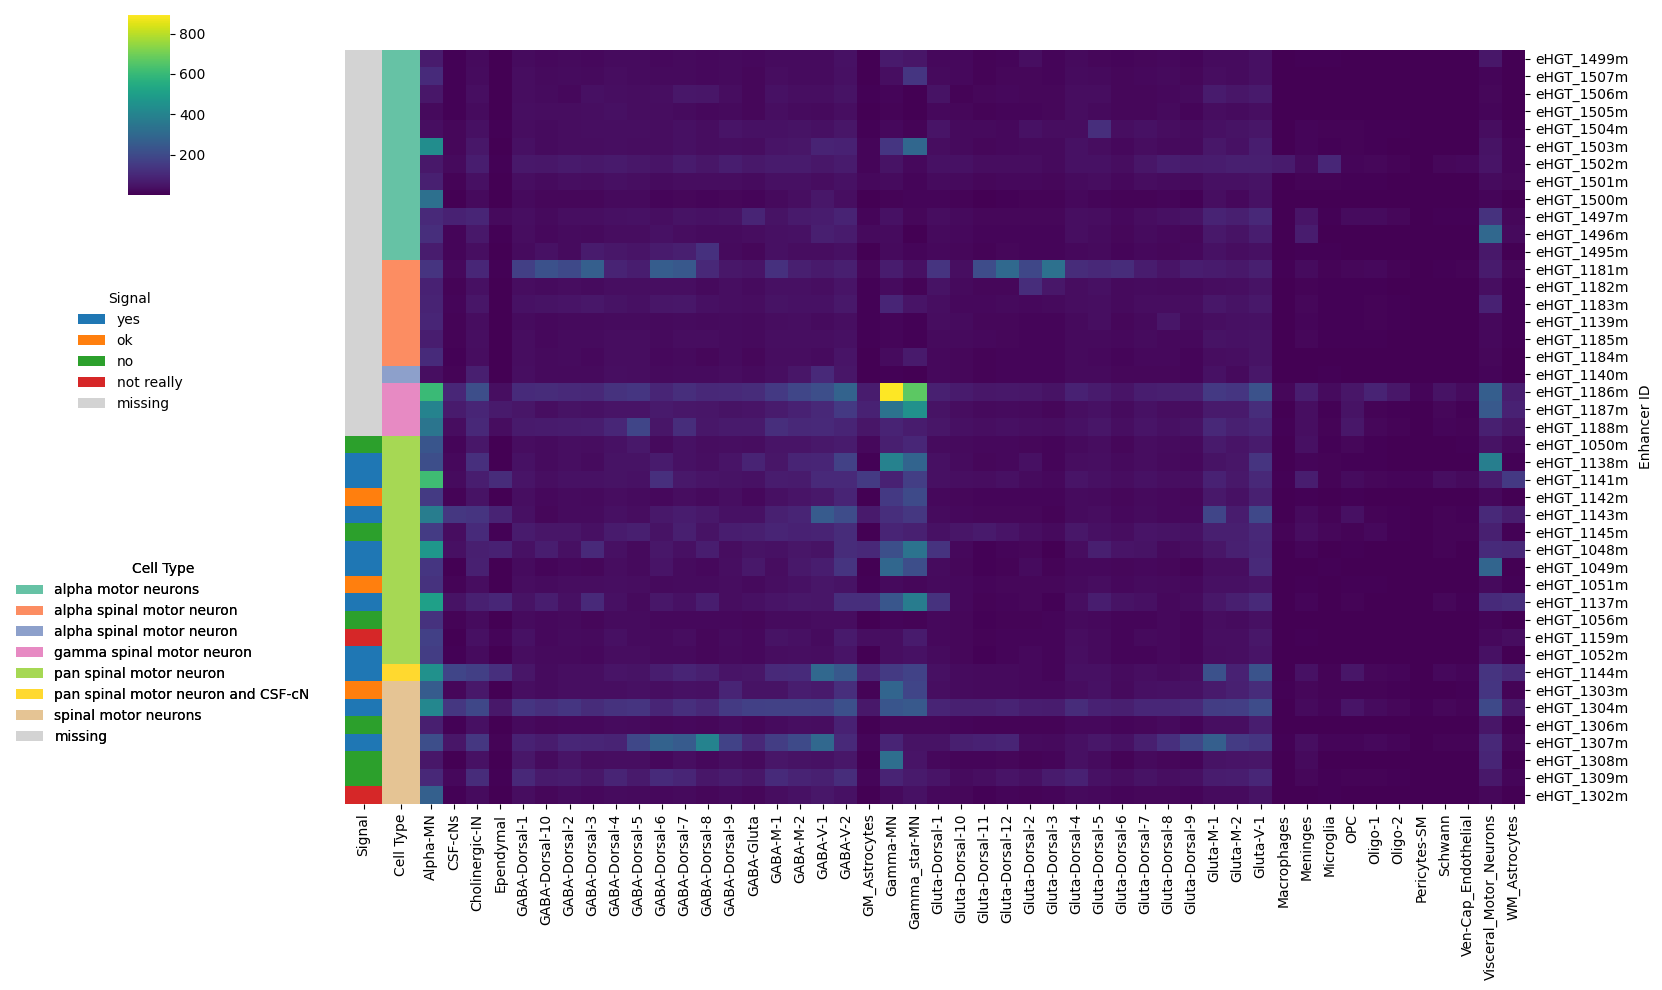

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

%matplotlib inline

# Ensure the base DataFrame is aligned
heatmap_df = pd.DataFrame(predictions, columns=output_names_macaque)
heatmap_df.index = df["Enhancer ID"]

# Align df to heatmap index
df_filtered = df.set_index("Enhancer ID").loc[heatmap_df.index]

# === SORT by 'Cell Type target' ===
df_filtered = df_filtered.sort_values("Cell Type target")
heatmap_df = heatmap_df.loc[df_filtered.index]

# Define palettes
signal_palette = {
    'yes': '#1f77b4',
    'ok': '#ff7f0e',
    'no': '#2ca02c',
    'not really': '#d62728'
}
signal_colors = df_filtered["Signal"].map(signal_palette).fillna("#d3d3d3")  # light gray for NaN

unique_celltypes = df_filtered["Cell Type target"].dropna().unique()
celltype_palette = dict(zip(unique_celltypes, sns.color_palette("Set2", len(unique_celltypes))))
celltype_colors = df_filtered["Cell Type target"].map(celltype_palette).fillna("#d3d3d3")

row_colors = pd.DataFrame({
    "Signal": signal_colors,
    "Cell Type": celltype_colors
}, index=heatmap_df.index)

# Plot clustermap
g = sns.clustermap(
    heatmap_df,
    cmap="viridis",
    row_colors=row_colors,
    figsize=(14, 10),
    xticklabels=True,
    yticklabels=True,
    row_cluster=False,  # disable row clustering
    col_cluster=False,  # preserve column order
    dendrogram_ratio=(.05, .05),
    cbar_pos=(-0.1, 0.8, 0.03, 0.18)
)

# === Add legends ===
signal_handles = [Patch(facecolor=color, label=label) for label, color in signal_palette.items()]
signal_handles.append(Patch(facecolor="#d3d3d3", label="missing"))

celltype_handles = [Patch(facecolor=color, label=label) for label, color in celltype_palette.items()]
celltype_handles.append(Patch(facecolor="#d3d3d3", label="missing"))

signal_legend = g.ax_row_dendrogram.legend(
    handles=signal_handles,
    title="Signal",
    loc="center left",
    bbox_to_anchor=(-3.5, 0.6),
    frameon=False
)

celltype_legend = g.ax_row_dendrogram.legend(
    handles=celltype_handles,
    title="Cell Type",
    loc="center left",
    bbox_to_anchor=(-4.5, 0.2),
    frameon=False
)

g.fig.add_artist(signal_legend)
g.fig.add_artist(celltype_legend)

plt.show()

In [12]:
predictions_mouse = crested.tl.predict(df["sequence"].tolist(), mouse_model)
predictions_macaque = crested.tl.predict(df["sequence"].tolist(), macaque_model)

2025-06-09 09:10:09.333279: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_369', 280 bytes spill stores, 280 bytes spill loads

2025-06-09 09:10:09.385685: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_369', 4 bytes spill stores, 4 bytes spill loads



1/2 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step

2025-06-09 09:10:10.934254: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_369', 204 bytes spill stores, 204 bytes spill loads



2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


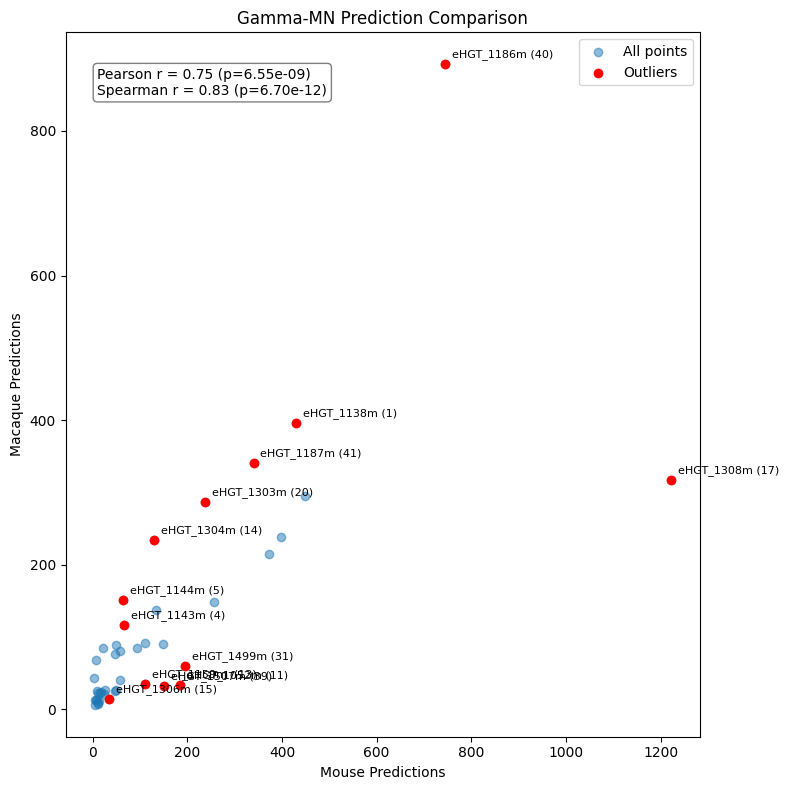

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from statsmodels.robust.scale import mad  # Median Absolute Deviation

cell_type = 'Gamma-MN'

# Get indices
mouse_idx = np.where(np.array(adata_mouse.obs_names) == cell_type)[0][0]
macaque_idx = np.where(np.array(adata_macaque.obs_names) == cell_type)[0][0]

# Extract predictions
x = predictions_mouse[:, mouse_idx]
y = predictions_macaque[:, macaque_idx]

# Fit linear regression
model = LinearRegression().fit(x.reshape(-1, 1), y)
y_pred = model.predict(x.reshape(-1, 1))
residuals = np.abs(y - y_pred)

# Define outliers based on residual threshold
threshold = 3 * mad(residuals)
outlier_idx = np.where(residuals > threshold)[0]

# Correlation coefficients
pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

# Plot
plt.figure(figsize=(8, 8))
plt.scatter(x, y, alpha=0.5, label='All points')
plt.scatter(x[outlier_idx], y[outlier_idx], color='red', label='Outliers')

# Annotate correlation
plt.text(0.05, 0.95,
         f"Pearson r = {pearson_r:.2f} (p={pearson_p:.2e})\n"
         f"Spearman r = {spearman_r:.2f} (p={spearman_p:.2e})",
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round'))

# Annotate outliers
for i in outlier_idx:
    enhancer_id = df['Enhancer ID'].iloc[i]
    plt.annotate(enhancer_id + " ("+str(i)+")", (x[i], y[i]),
                 textcoords="offset points", xytext=(5, 5), ha='left', fontsize=8)

plt.xlabel("Mouse Predictions")
plt.ylabel("Macaque Predictions")
plt.title(f"{cell_type} Prediction Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Example regions

In [14]:
idx = 8
seq = df.iloc[idx]['sequence']
id_ = df.iloc[idx]['Enhancer ID']
target = df.iloc[idx]['Cell Type target']
len_ = np.sum(np.array(list(seq)) != "N")
print(id_)
print(target)
print(len_)

eHGT_1049m
pan spinal motor neuron
677


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 643ms/step


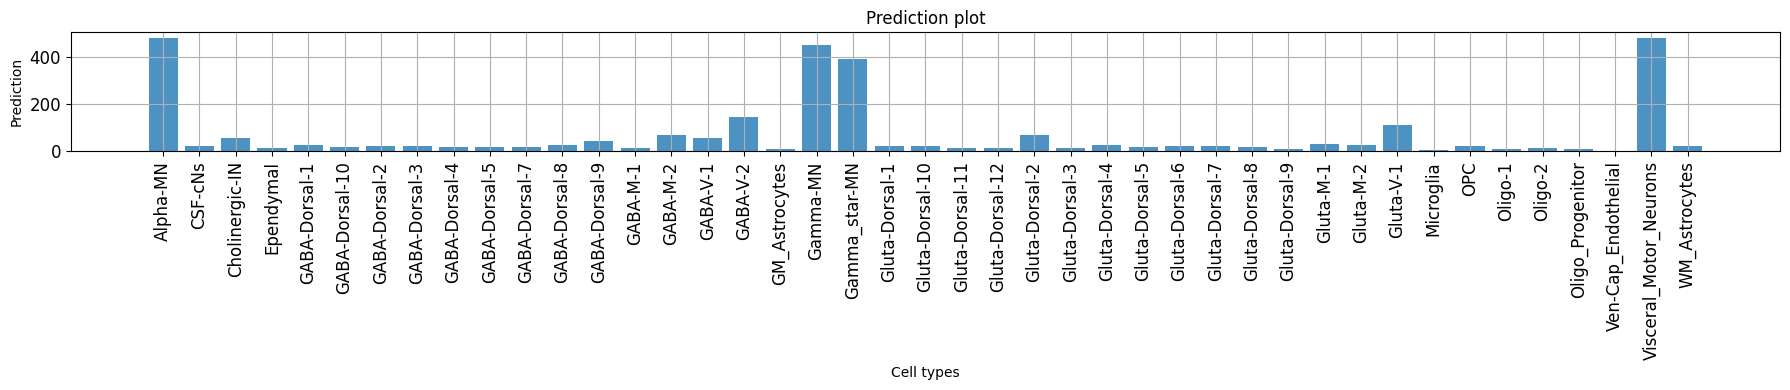

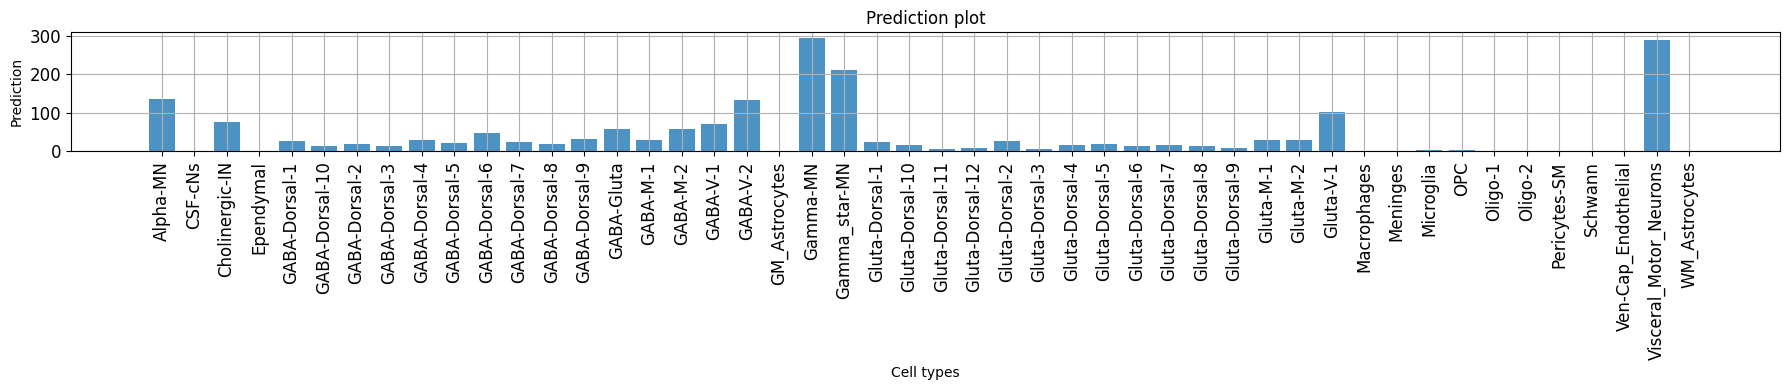

In [15]:
prediction_macaque = crested.tl.predict(seq, macaque_model)
prediction_mouse = crested.tl.predict(seq, mouse_model)

crested.pl.bar.prediction(prediction_mouse, classes=output_names_mouse, x_label_rotation=90, height=4)
crested.pl.bar.prediction(prediction_macaque, classes=output_names_macaque, x_label_rotation=90, height=4)

In [16]:
classes_of_interest = ["Alpha-MN","Gamma-MN", "Gamma_star-MN", "Visceral_Motor_Neurons"]
class_idx = list(adata_macaque.obs_names.get_indexer(classes_of_interest))
regions_of_interest=[seq]
scores_mac, one_hot_encoded_sequences = crested.tl.contribution_scores(
    regions_of_interest,
    target_idx=class_idx,
    model=macaque_model,
    method='integrated_grad'
)

class_idx = list(adata_mouse.obs_names.get_indexer(classes_of_interest))
regions_of_interest=[seq]
scores_mou, one_hot_encoded_sequences = crested.tl.contribution_scores(
    regions_of_interest,
    target_idx=class_idx,
    model=mouse_model,
    method='integrated_grad'
)

2025-06-09T09:10:15.139594-0700 INFO Calculating contribution scores for 4 class(es) and 1 region(s).


Model: 100%|██████████| 1/1 [00:08<00:00,  8.74s/it]

2025-06-09T09:10:23.880477-0700 INFO Calculating contribution scores for 4 class(es) and 1 region(s).



Model: 100%|██████████| 1/1 [00:00<00:00,  3.06it/s]


In [17]:
class_idx

[np.int64(0), np.int64(18), np.int64(19), np.int64(41)]

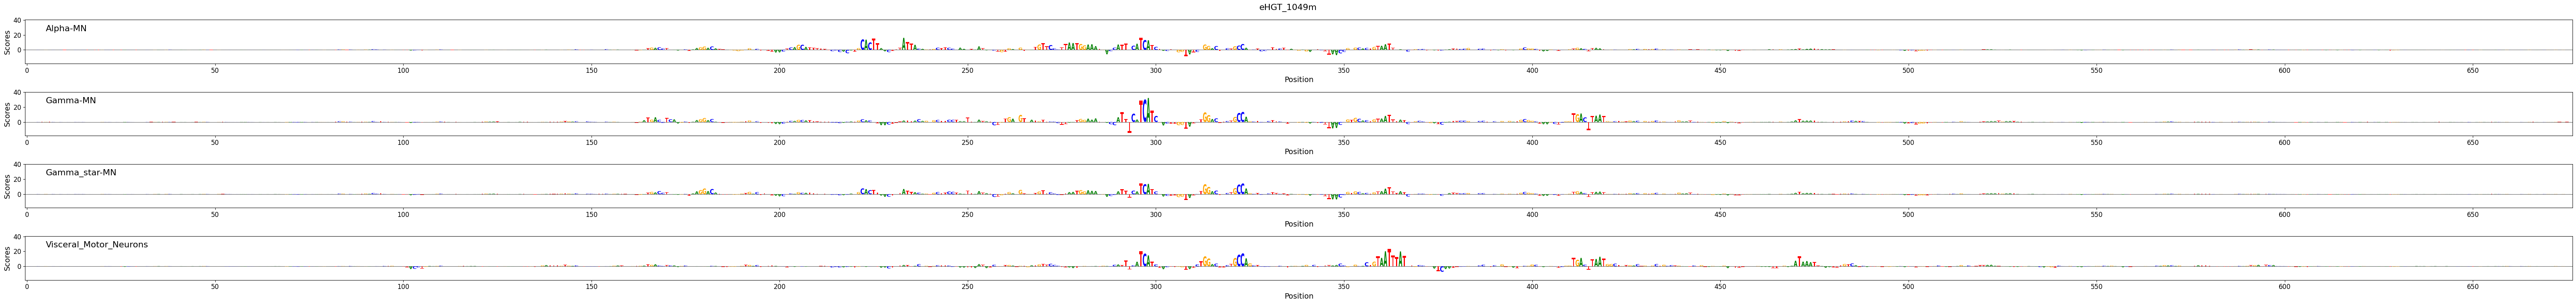

In [18]:
%matplotlib inline
crested.pl.patterns.contribution_scores(
    scores_mou,
    one_hot_encoded_sequences,
    sequence_labels=[""],
    class_labels=classes_of_interest,
    zoom_n_bases=len_,
    title=id_
)  # zoom in on the center 500bp

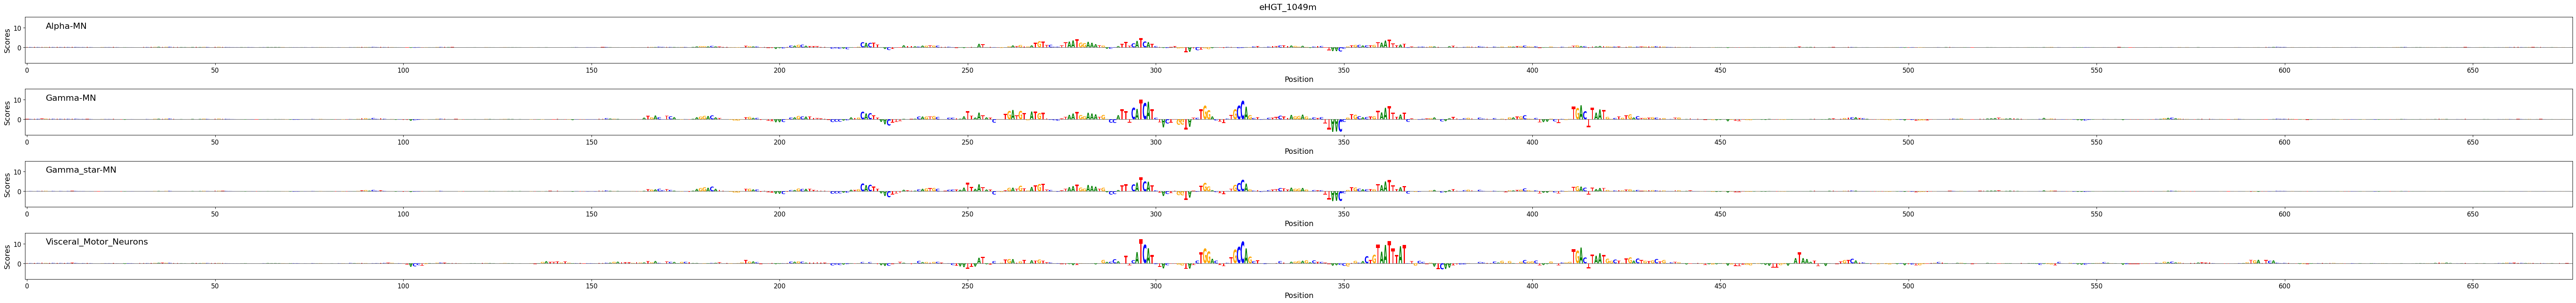

In [19]:
%matplotlib inline
crested.pl.patterns.contribution_scores(
    scores_mac,
    one_hot_encoded_sequences,
    sequence_labels=[""],
    class_labels=classes_of_interest,
    zoom_n_bases=len_,
    title=id_
) 

# Extra list

In [8]:
import pysam
genome_macaque  = "/allen/programs/celltypes/workgroups/rnaseqanalysis/references/macaque/ncbi/mmul10/genome/fasta/genome.fa"
genome_mouse  = "/allen/programs/celltypes/workgroups/rnaseqanalysis/references/mouse/10x/mm10/genome/fasta/genome.fa"
genome_human = "/allen/programs/celltypes/workgroups/rnaseqanalysis/references/human/10x/grch38.p2/genome/fasta/genome.fa"

In [9]:
macaque_chrom_map = load_macaque_chrom_map("mac_chrom.txt")

In [10]:
import pandas as pd
df = pd.read_csv('enh_list.csv', index_col='Plasmid ID')
df

,Project name,Cell type target class (SpC),Cell type target subclass/group (SpC),Species,Coordinates,Core,Level of labeling,Category,Note
Plasmid ID,,,,,,,,,
HCT1,Paper,Motor neuron,pan spinal motor neuron,Mouse,"chr14:32,468,473-32,469,163",NaN,5.0,NaN,yes
HCT2,NaN,Motor neuron,pan spinal motor neuron,Mouse,"chr14:32,265,147-32,265,998",NaN,5.0,NaN,yes
HCT6,NaN,Motor neuron,pan spinal motor neuron,Mouse,"chr5:104,239,701-104,240,770",NaN,5.0,NaN,yes
HCT7,NaN,Motor neuron,pan spinal motor neuron,Mouse,"chr5:104,470,842-104,471,492",NaN,3.0,NaN,ok
HCT8,NaN,Motor neuron,pan spinal motor neuron,Mouse,"chr1:187,052,314-187,053,069",NaN,3.0,NaN,yes
...,...,...,...,...,...,...,...,...,...
CN2602,NaN,Gluta,"Gluta-Dorsal-6, Gluta-Dorsal-7",Mouse,"chr14:50,995,280-50,995,748",NaN,2.0,NaN,sst/chodl (cortex)
CN3098,NaN,Astro-Ependymal,"Astrocytes, Ependymal",Human,chr6:44045591-44046117,NaN,3.0,NaN,astrocyte (cortex)
CN1852,NaN,"GABA, Gluta","GABA, Gluta",Mouse,chr1:182821907-182822681,combi,1.0,NaN,hsyn1


In [11]:
import pysam
from tqdm import tqdm

species_to_genome = {
    "Macaque": pysam.FastaFile(genome_macaque),
    "Mouse": pysam.FastaFile(genome_mouse),
    "Human": pysam.FastaFile(genome_human),
}

df = assign_sequences(
    df,
    species_to_genome=species_to_genome,
    target_length=2114,
    macaque_chrom_map=macaque_chrom_map
)


[DEBUG][HCT1] Original coords = chr14:32468473-32469163
[DEBUG][HCT1] Raw length = 690
[DEBUG][HCT1] Original padded = 2114 (L=712, R=712)
[DEBUG][HCT1] core='nan' → no bashing
[DEBUG][HCT2] Original coords = chr14:32265147-32265998
[DEBUG][HCT2] Raw length = 851
[DEBUG][HCT2] Original padded = 2114 (L=631, R=632)
[DEBUG][HCT2] core='nan' → no bashing
[DEBUG][HCT6] Original coords = chr5:104239701-104240770
[DEBUG][HCT6] Raw length = 1069
[DEBUG][HCT6] Original padded = 2114 (L=522, R=523)
[DEBUG][HCT6] core='nan' → no bashing
[DEBUG][HCT7] Original coords = chr5:104470842-104471492
[DEBUG][HCT7] Raw length = 650
[DEBUG][HCT7] Original padded = 2114 (L=732, R=732)
[DEBUG][HCT7] core='nan' → no bashing
[DEBUG][HCT8] Original coords = chr1:187052314-187053069
[DEBUG][HCT8] Raw length = 755
[DEBUG][HCT8] Original padded = 2114 (L=679, R=680)
[DEBUG][HCT8] core='nan' → no bashing
[DEBUG][HCT9] Original coords = chr1:187052266-187053125
[DEBUG][HCT9] Raw length = 859
[DEBUG][HCT9] Original 

In [12]:
import crested
df_valid = df[df["Sequence"].notna()]
df_valid = df_valid[~df_valid.index.duplicated()].copy()

prediction_specificity = crested.pp._utils._calc_proportion(crested.tl.predict(df_valid["Sequence"].tolist(), mouse_model))
prediction_strength = np.log1p(crested.tl.predict(df_valid["Sequence"].tolist(), mouse_model))

I0000 00:00:1752264696.137111 2220934 service.cc:148] XLA service 0x7fa508003360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752264696.137130 2220934 service.cc:156]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB, Compute Capability 8.0
2025-07-11 13:11:36.157371: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1752264696.225105 2220934 cuda_dnn.cc:529] Loaded cuDNN version 90600
2025-07-11 13:11:36.951513: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_369', 400 bytes spill stores, 400 bytes spill loads

2025-07-11 13:11:37.112573: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_369_0', 116 byte

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


I0000 00:00:1752264714.289877 2220934 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.patches import Patch
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
from matplotlib.colorbar import ColorbarBase
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Step 2: Build heatmap_df directly
heatmap_df = pd.DataFrame(prediction_strength, columns=output_names_mouse, index=df_valid.index)

# Step 2: Prepare numeric level values
level_series = df_valid["Level of labeling"]
norm = Normalize(vmin=level_series.min(), vmax=level_series.max())
cmap = get_cmap("viridis")  # Or use "plasma", "rocket", "magma", etc.

# Step 3: Map levels to colors
row_colors = level_series.map(lambda x: cmap(norm(x)) if pd.notna(x) else (1.0, 1.0, 1.0, 1.0))  # white for NaNs

# === Clustermap ===
g = sns.clustermap(
    heatmap_df,
    cmap="viridis",
    row_colors=row_colors,
    figsize=(14, 10),
    xticklabels=True,
    yticklabels=True,
    row_cluster=False,
    col_cluster=False,
    dendrogram_ratio=(.05, .05),
    cbar_pos=(-0.1, 0.8, 0.03, 0.18)
)

# === Colorbar for level of labeling ===
# Add a colorbar to explain gradient
from matplotlib.colorbar import ColorbarBase
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Create a separate axis for the colorbar
cax = make_axes_locatable(g.ax_heatmap).append_axes("left", size="3%", pad=0.8)
cb = ColorbarBase(cax, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label("Level of labeling")

plt.show()

/home/niklas.kempynck/wandb_tmp/ipykernel_2220858/1321320882.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("viridis")  # Or use "plasma", "rocket", "magma", etc.


In [14]:
reordered_classes = ["Alpha-MN","Gamma-MN","Gamma_star-MN","Visceral_Motor_Neurons","Chol-IN","Gluta-Dorsal-2","Gluta-Dorsal-3","Gluta-Dorsal-1","Gluta-Dorsal-5","Gluta-Dorsal-7","Gluta-Dorsal-11","Gluta-Dorsal-12",
                     "Gluta-Dorsal-6","Gluta-Dorsal-4","Gluta-Dorsal-8","Gluta-Dorsal-9","Gluta-Dorsal-10","Gluta-V-1","Gluta-M-1","Gluta-M-2","GABA-Dorsal-2","GABA-Dorsal-3","GABA-Dorsal-10","GABA-Dorsal-6",
                     "GABA-Dorsal-4","GABA-Dorsal-8","GABA-Dorsal-7","GABA-Dorsal-9","GABA-Dorsal-5","GABA-Dorsal-1","GABA-M-1","GABA-M-2","GABA-V-1","GABA-V-2","CSF-cNs","GABA-Glut","Ven-Cap_Endothelial","Meninges",
                     "Pericytes-SM","Ependymal","Oligo-1","Oligo-2","Oligo Progenitor","OPC","WM_Astrocytes","GM_Astrocytes","Schwann","Lymphocytes","Microglia","Macrophages"]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Niklas/software/HMBA_Genomics/SpinalCord/crested_analysis/helper_functions.py:303: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


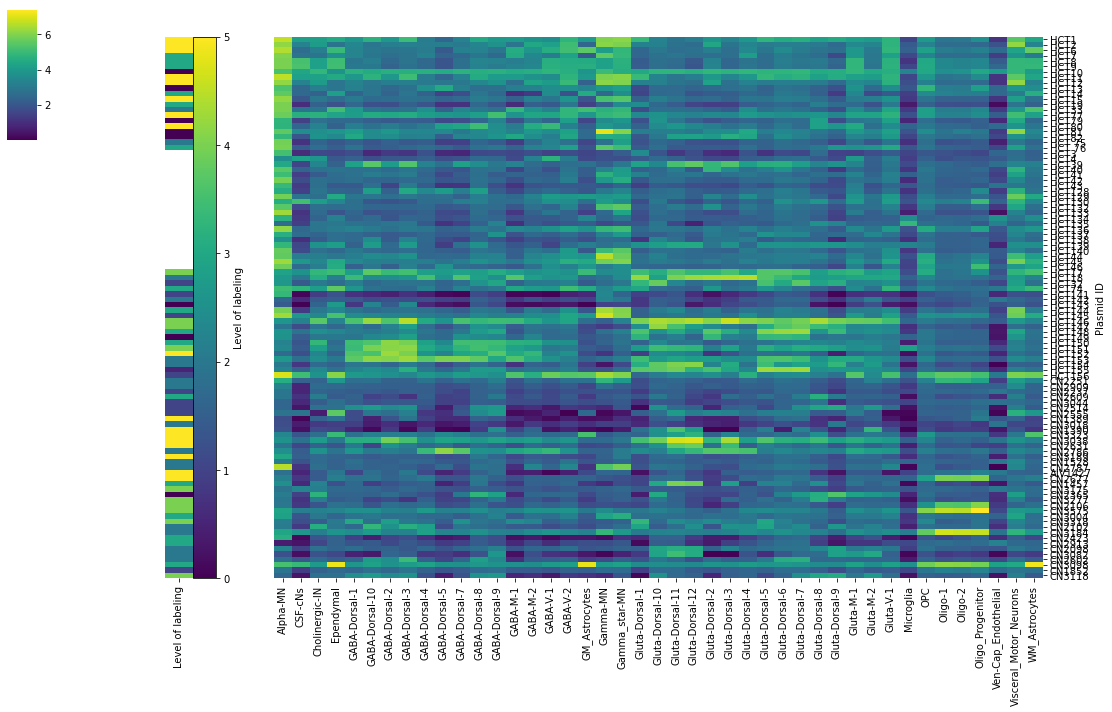

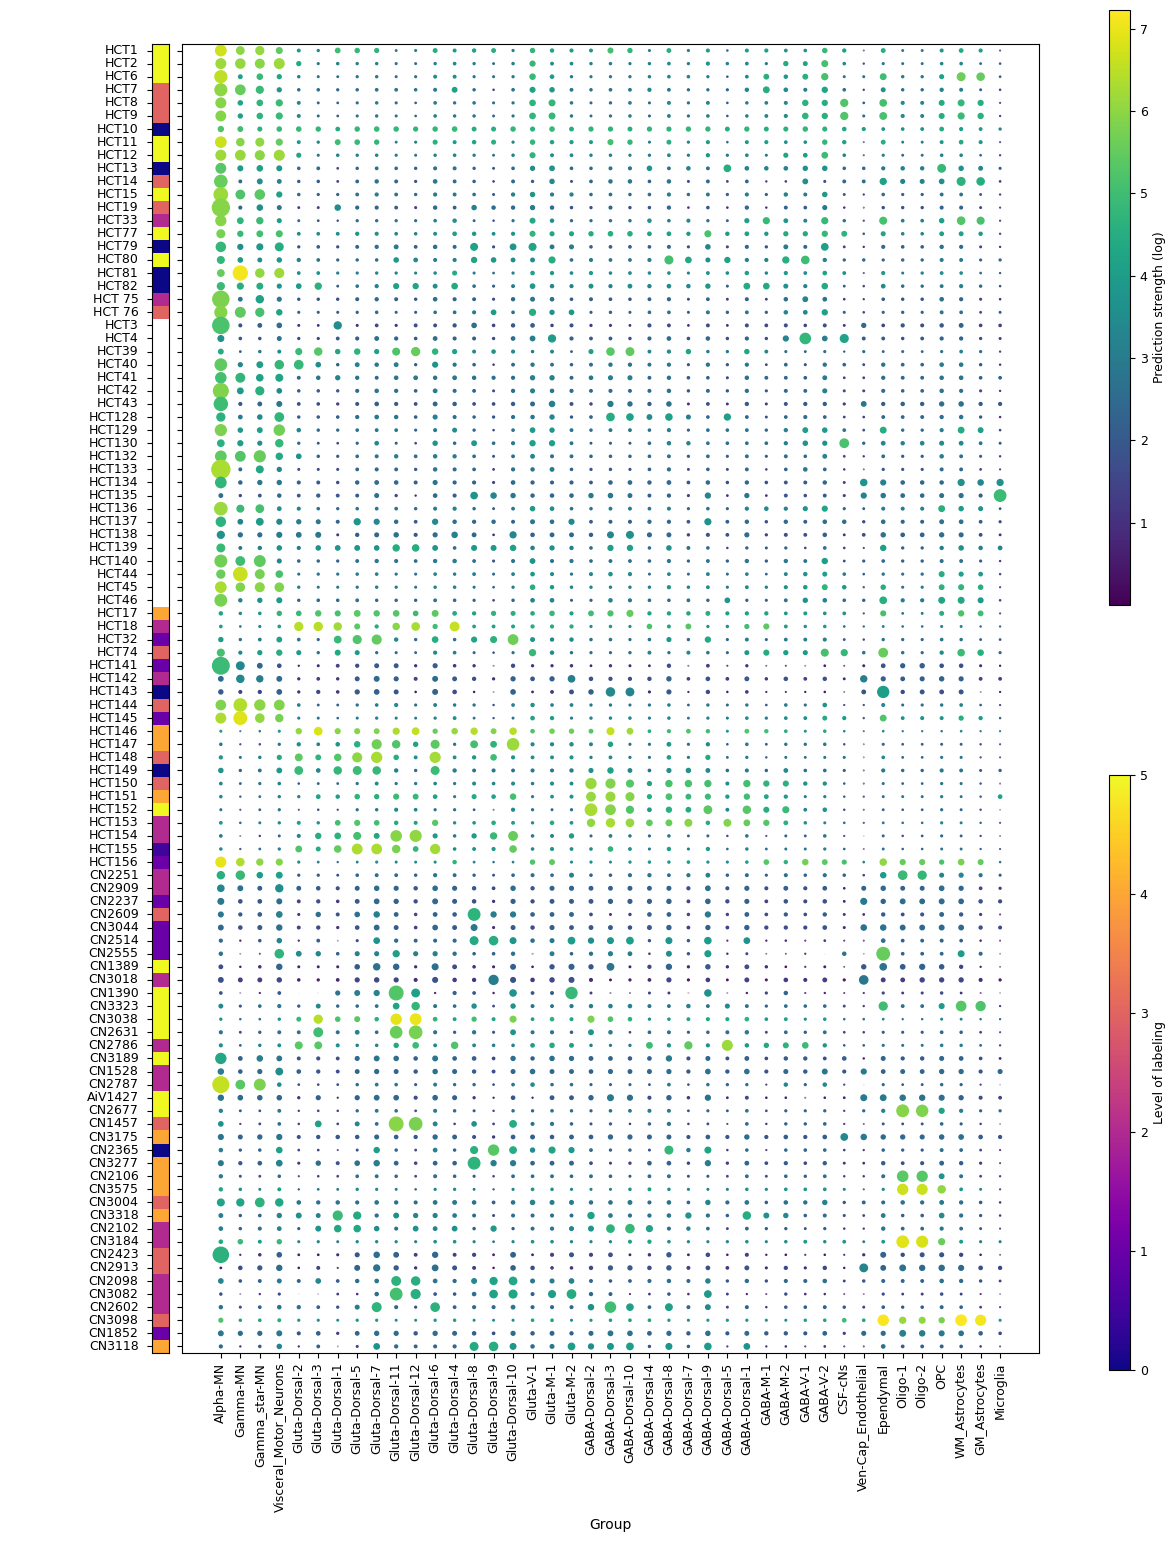

In [15]:
%matplotlib inline
prediction_specificity = crested.pp._utils._calc_proportion(crested.tl.predict(df_valid["Sequence"].tolist(), mouse_model))
prediction_strength = np.log1p(crested.tl.predict(df_valid["Sequence"].tolist(), mouse_model))

# Reorder using filtered class list
prediction_specificity, class_names_filtered = reorder_predictions(
    prediction_specificity, output_names_mouse, reordered_classes
)
prediction_strength, _ = reorder_predictions(
    prediction_strength, output_names_mouse, reordered_classes
)

plot_prediction_scatter_grid(prediction_strength, prediction_specificity, df_valid, class_names_filtered)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Niklas/software/HMBA_Genomics/SpinalCord/crested_analysis/helper_functions.py:303: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


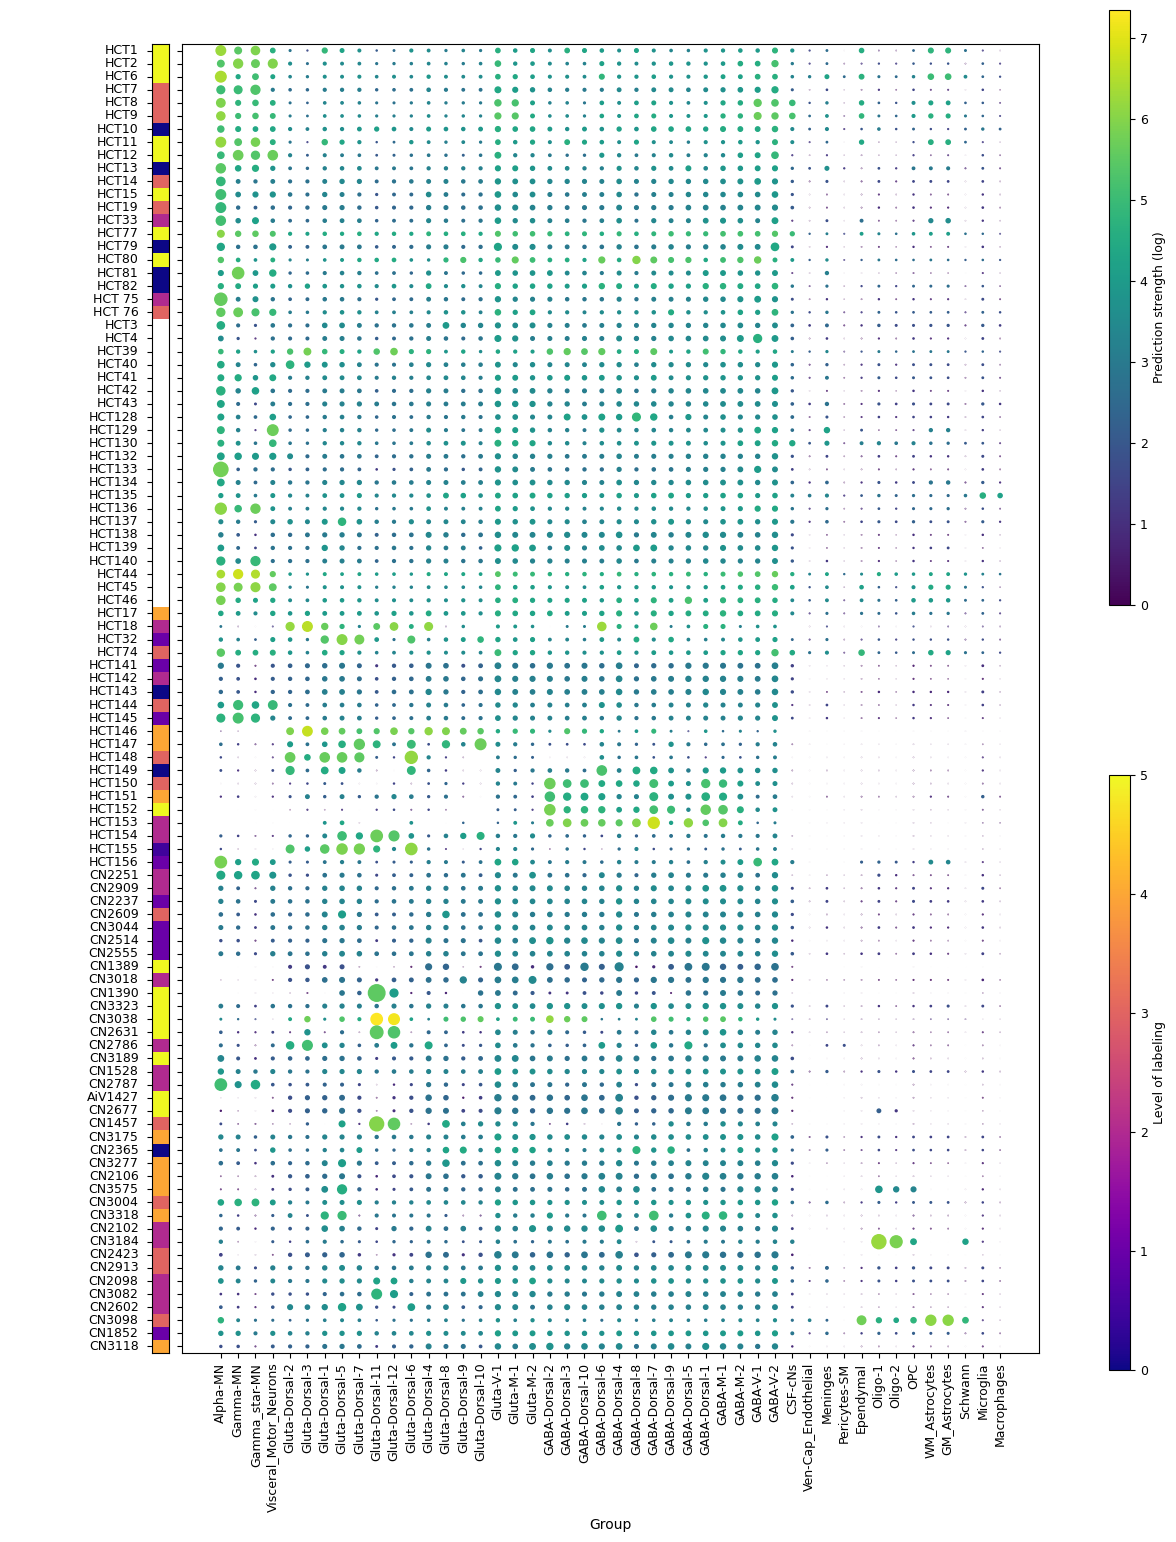

In [16]:
prediction_specificity = crested.pp._utils._calc_proportion(crested.tl.predict(df_valid["Sequence"].tolist(), macaque_model))
prediction_strength = np.log1p(crested.tl.predict(df_valid["Sequence"].tolist(), macaque_model))
# Reorder using filtered class list
prediction_specificity, class_names_filtered = reorder_predictions(
    prediction_specificity, output_names_macaque, reordered_classes
)
prediction_strength, _ = reorder_predictions(
    prediction_strength, output_names_macaque, reordered_classes
)
plot_prediction_scatter_grid(prediction_strength, prediction_specificity, df_valid, class_names_filtered)

2025-07-11 13:12:00.845443: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_369', 400 bytes spill stores, 400 bytes spill loads

2025-07-11 13:12:01.108506: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_369', 48 bytes spill stores, 48 bytes spill loads

2025-07-11 13:12:01.152023: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_369', 12 bytes spill stores, 12 bytes spill loads



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Niklas/software/HMBA_Genomics/SpinalCord/crested_analysis/helper_functions.py:303: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


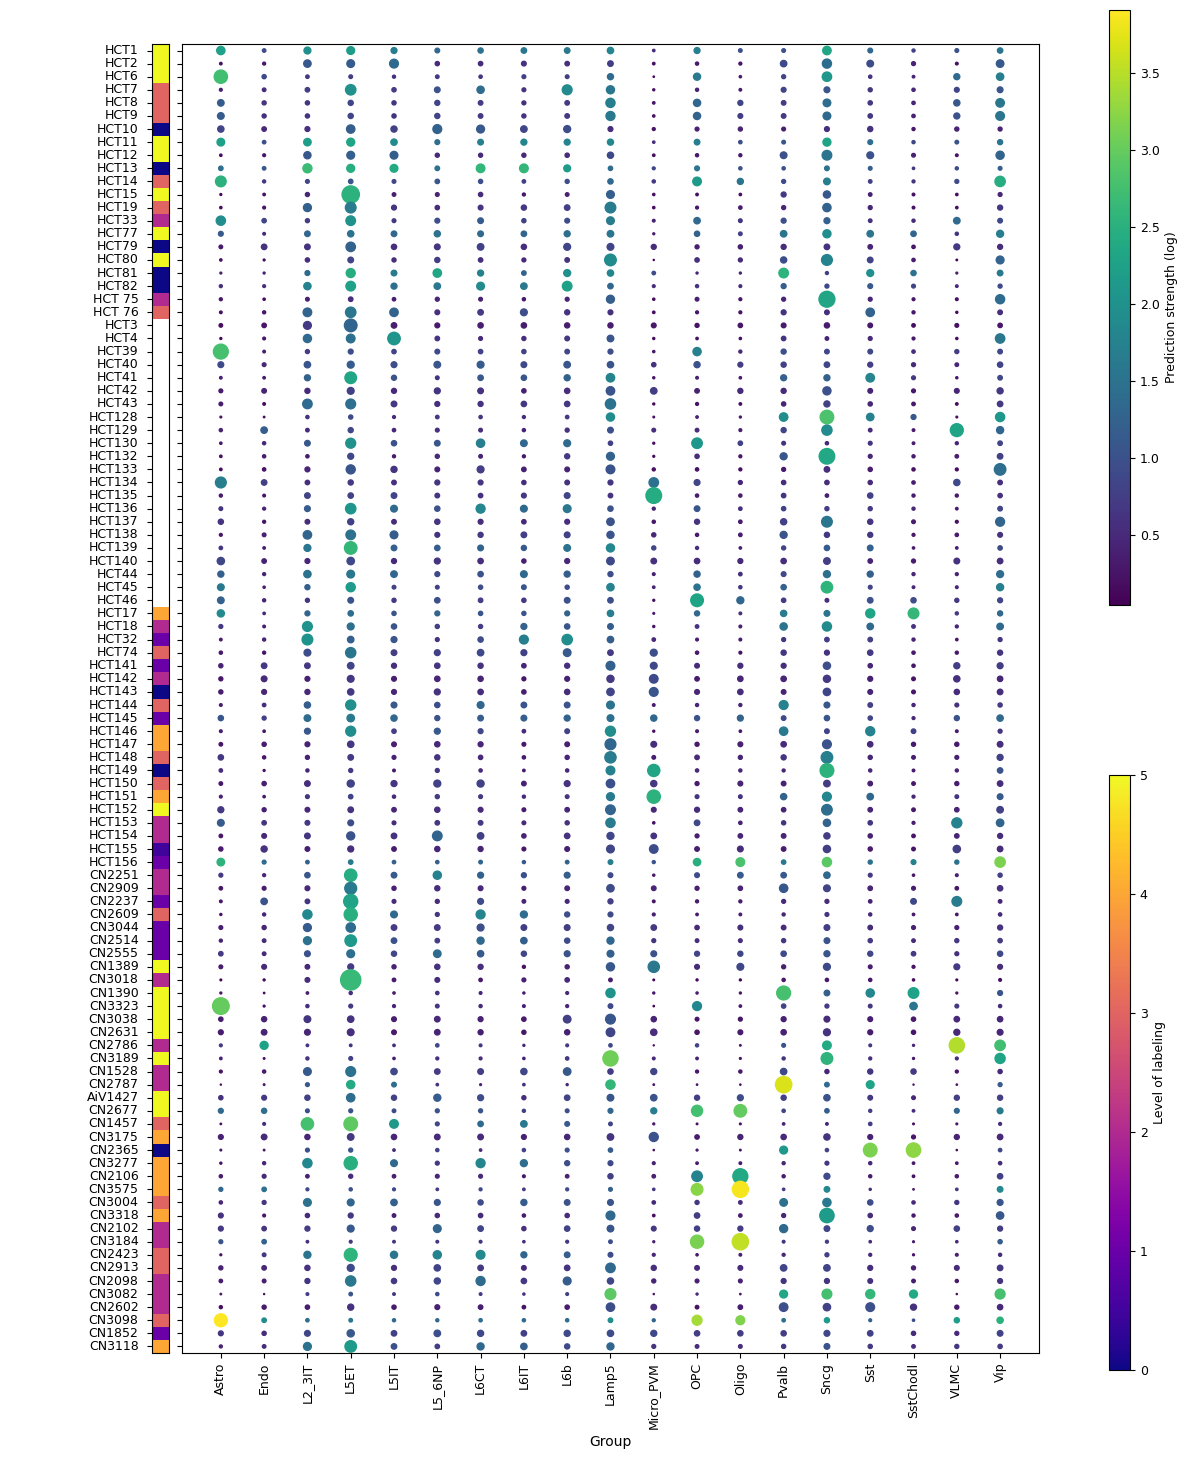

In [17]:
prediction_specificity = crested.pp._utils._calc_proportion(crested.tl.predict(df_valid["Sequence"].tolist(), model_biccn))
prediction_strength = np.log1p(crested.tl.predict(df_valid["Sequence"].tolist(), model_biccn))
plot_prediction_scatter_grid(prediction_strength, prediction_specificity, df_valid, output_names_biccn)

2025-07-11 13:12:03.850775: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_369', 196 bytes spill stores, 184 bytes spill loads

2025-07-11 13:12:03.901526: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_369', 8 bytes spill stores, 8 bytes spill loads

2025-07-11 13:12:04.437084: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_369', 220 bytes spill stores, 220 bytes spill loads

2025-07-11 13:12:07.415618: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 162.53GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more me

10/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

2025-07-11 13:12:11.251705: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_369', 196 bytes spill stores, 184 bytes spill loads

2025-07-11 13:12:11.284318: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_369', 8 bytes spill stores, 8 bytes spill loads

2025-07-11 13:12:11.799165: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_369', 164 bytes spill stores, 164 bytes spill loads

2025-07-11 13:12:13.570060: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 146.28GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more me

13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 422ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Niklas/software/HMBA_Genomics/SpinalCord/crested_analysis/helper_functions.py:303: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


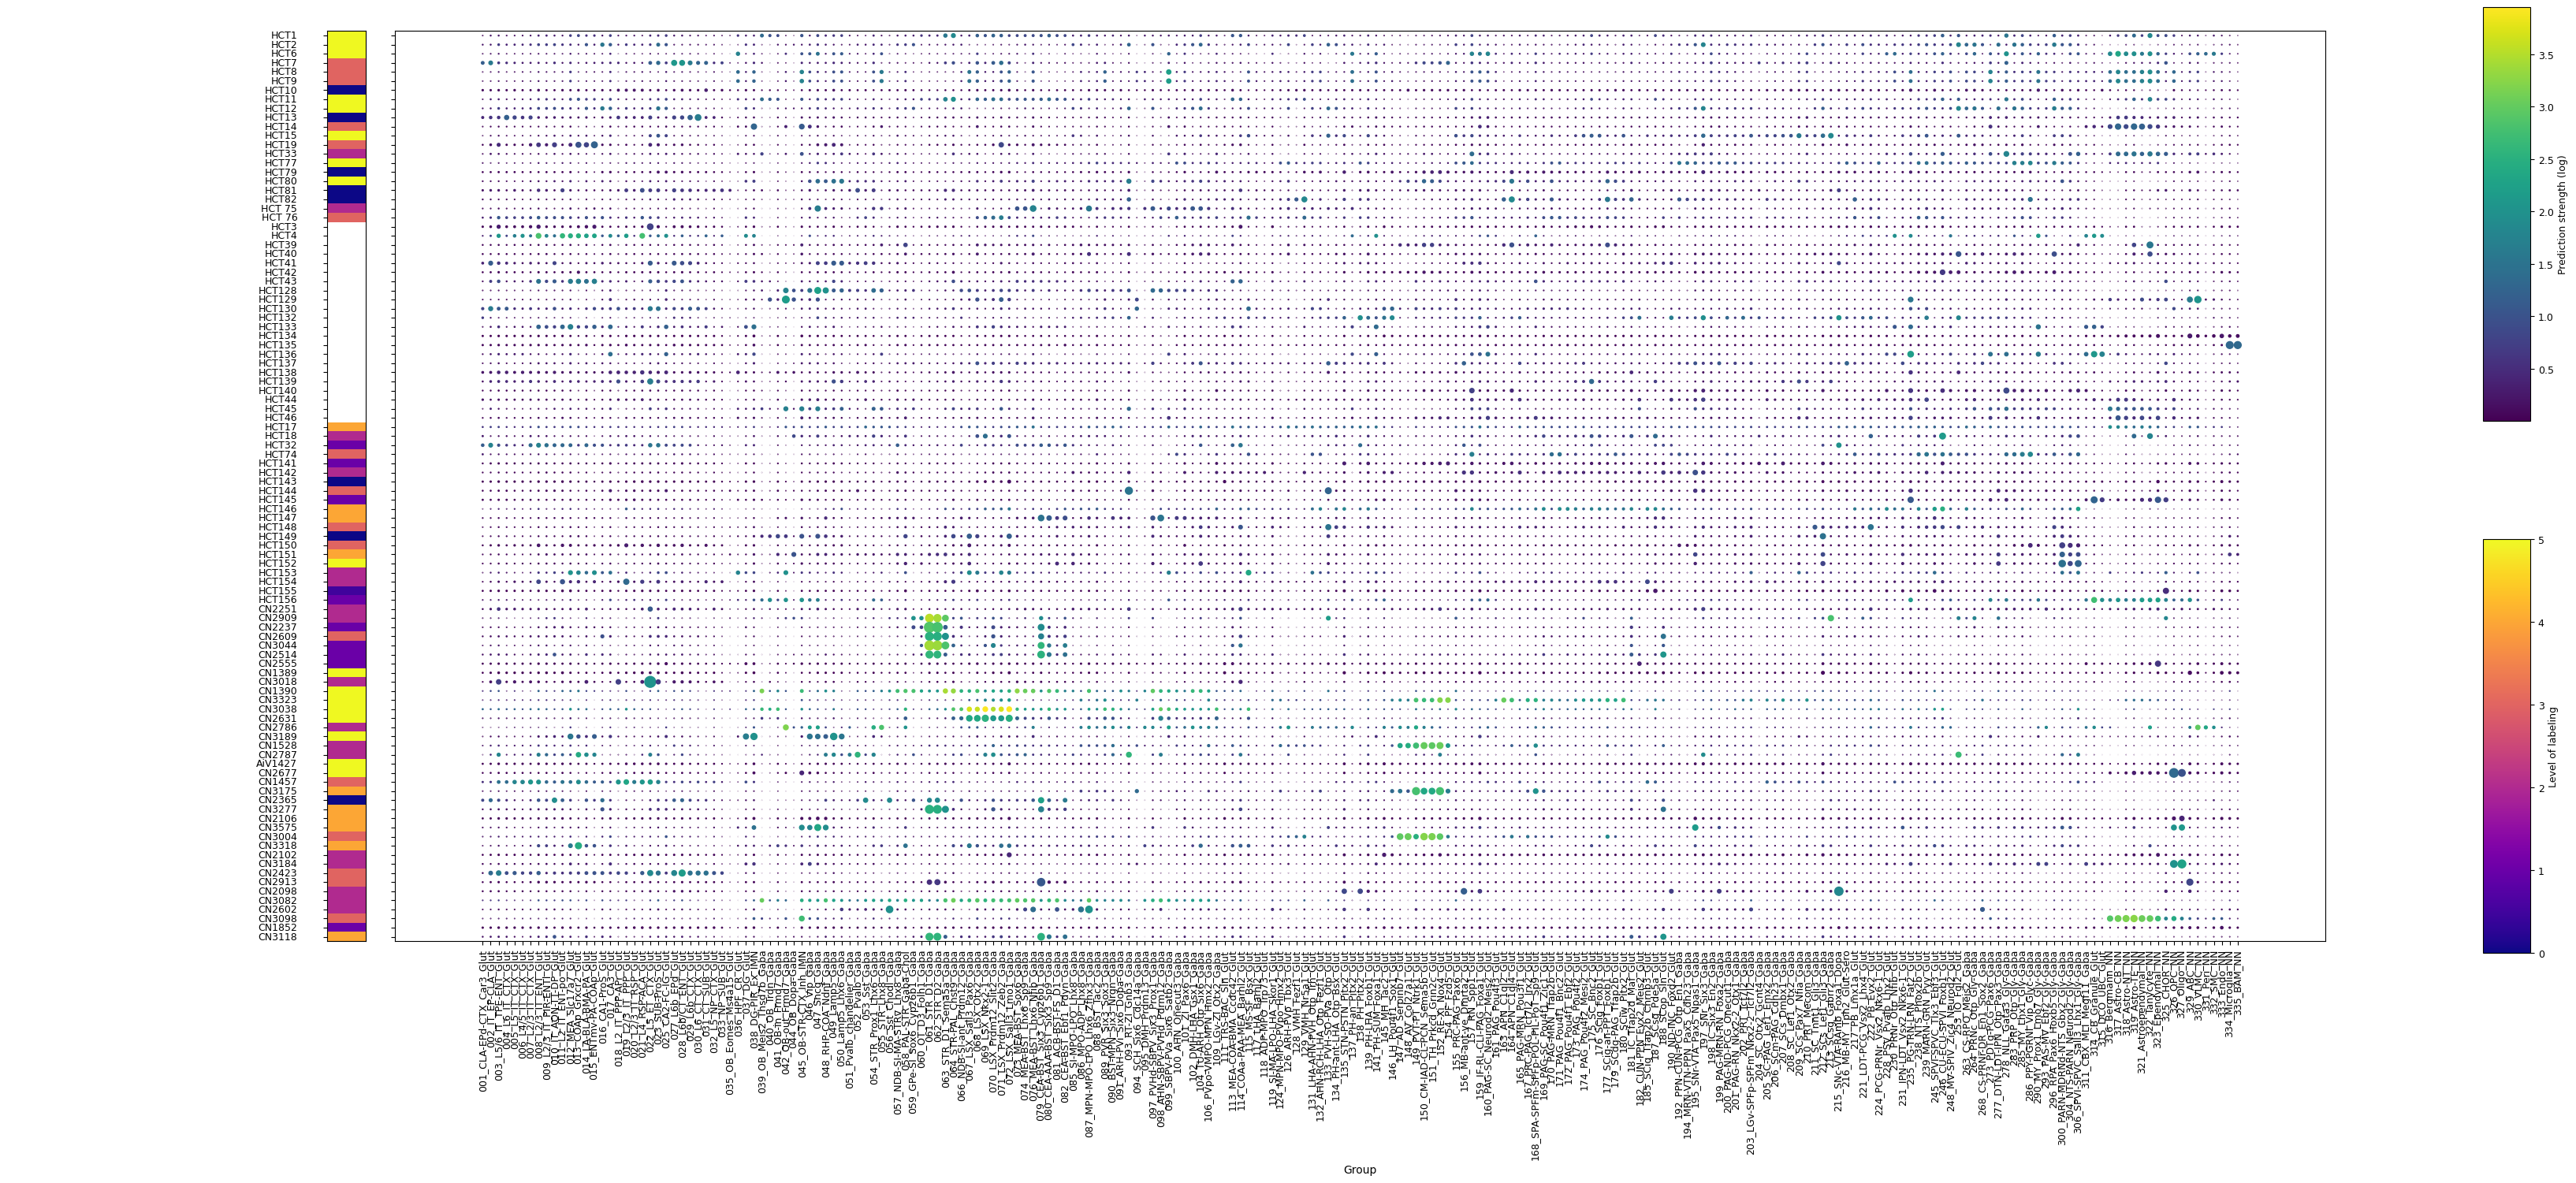

In [18]:
prediction_specificity = crested.pp._utils._calc_proportion(crested.tl.predict(df_valid["Sequence"].tolist(), model_wmb, batch_size=8))
prediction_strength = np.log1p(crested.tl.predict(df_valid["Sequence"].tolist(), model_wmb, batch_size=8))
plot_prediction_scatter_grid(prediction_strength, prediction_specificity, df_valid, output_names_wmb, figsize=(40,15))

In [19]:
# Get predictions
prediction_specificity = crested.pp._utils._calc_proportion(
    crested.tl.predict(df_valid["Sequence"].tolist(), model_wmb, batch_size=8)
)
prediction_strength = crested.tl.predict(df_valid["Sequence"].tolist(), model_wmb, batch_size=8)

specificity_df = pd.DataFrame(
    prediction_specificity,
    index=df_valid.index,
    columns=[f"Specificity_{name}" for name in output_names_wmb]
)

strength_df = pd.DataFrame(
    prediction_strength,
    index=df_valid.index,
    columns=[f"Strength_{name}" for name in output_names_wmb]
)

log_strength_df = pd.DataFrame(
    np.log1p(prediction_strength),
    index=df_valid.index,
    columns=[f"Log_strength_{name}" for name in output_names_wmb]
)

# Combine and write to CSV
result_df = pd.concat([specificity_df, strength_df, log_strength_df], axis=1)
result_df.to_csv("WholeMouseBrain_predictions_SpC_enhancers.csv")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [54]:
import numpy as np
enh = 'CN3038'
enh = 'CN1457'
#enh = 'CN3189'
enh = 'CN3277'
enh='CN3038'
enh='HCT128'

idx = np.argwhere(df_valid.index==enh)[0,0]
seq = df_valid.iloc[idx]['Sequence']
id_ = df_valid.index[idx]
len_ = np.sum(np.array(list(seq)) != "N")
print(id_)
print(len_)

HCT128
749


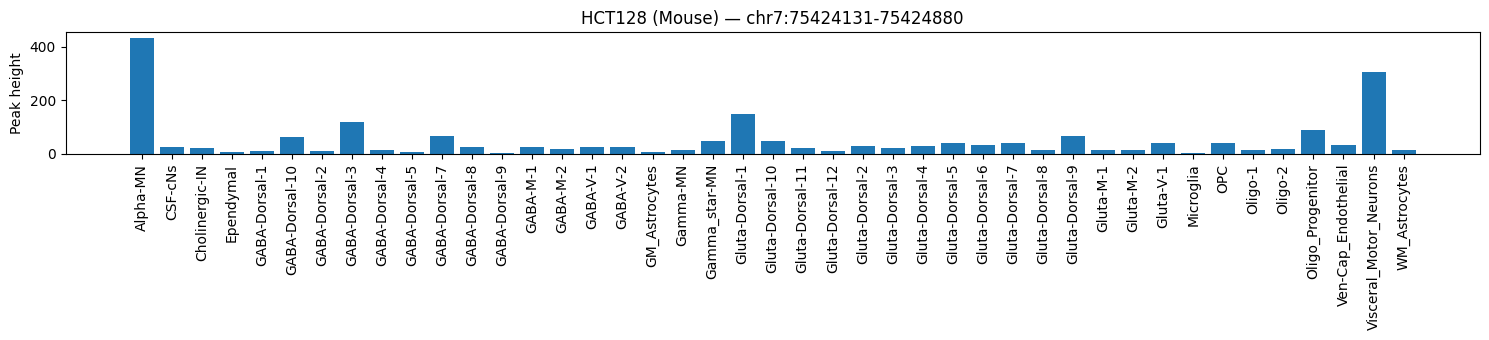

In [55]:
import os
import pyBigWig
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# === Predefined BigWig folders ===
species_folders = {
    "Mouse": "/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/OCTO/aibs-octo-dnaseq-modeling/spinal_cord/data/mouse/bigwig/",
    "Macaque": "/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/OCTO/aibs-octo-dnaseq-modeling/spinal_cord/data/macaque/bigwig/",
    "Human": "/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/OCTO/aibs-octo-dnaseq-modeling/spinal_cord/data/human/bigwig/"
}

adatas = {
    "Mouse": adata_mouse,
    "Macaque": adata_macaque,
    "Human": adata_human
}

# Load and clean coordinate table
df_valid["Core_Coordinates"] = df_valid["Core_Coordinates"].str.replace(",", "")

# === Parse coordinate ===
row = df_valid.iloc[idx]
species = row["Species"]
coord_str = row["Core_Coordinates"]

adata_ = adatas[species]
norm_vals = adata_.obsm['weights']
clss = np.array(adata_.obs_names)

def parse_coord(coord_str):
    chrom, rest = coord_str.split(":")
    start, end = map(int, rest.split("-"))
    return chrom, start, end

chrom, start, end = parse_coord(coord_str)

if species == 'Macaque':
    chrom = macaque_chrom_map[chrom]

# === Get folder and files ===
if species not in species_folders:
    raise ValueError(f"Species '{species}' not recognized")

bw_folder = species_folders[species]
bw_files = sorted(f for f in os.listdir(bw_folder) if f.endswith((".bw", ".bigWig")))

# === Collect values ===
values = []
labels = []

for cls in clss:
    cls = cls+'.bw'
    bw_path = os.path.join(bw_folder, cls)
    try:
        bw = pyBigWig.open(bw_path)
        signal = bw.values(chrom, start, end, numpy=True)
        total_signal = float("nan") if signal is None else np.nansum(signal)
    except RuntimeError:
        total_signal = float("nan")
    finally:
        bw.close()
    values.append(total_signal)
    labels.append(cls[:-3])

values = norm_vals * values
# === Plot ===
plt.figure(figsize=(15, 3.5))
plt.bar(labels, values)
plt.title(f"{df_valid.index[idx]} ({species}) — {chrom}:{start}-{end}")
plt.ylabel("Peak height")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


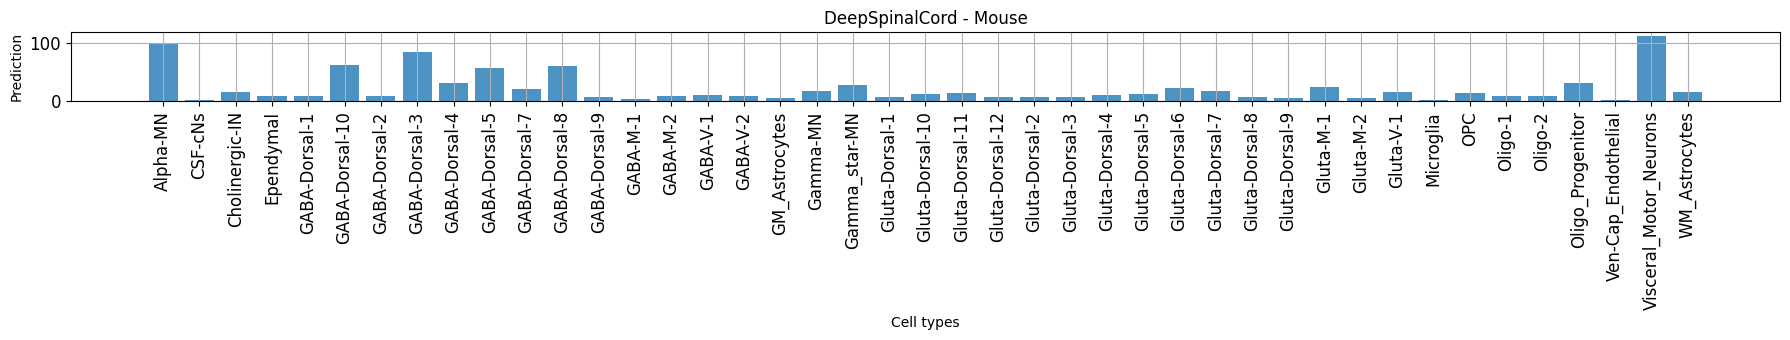

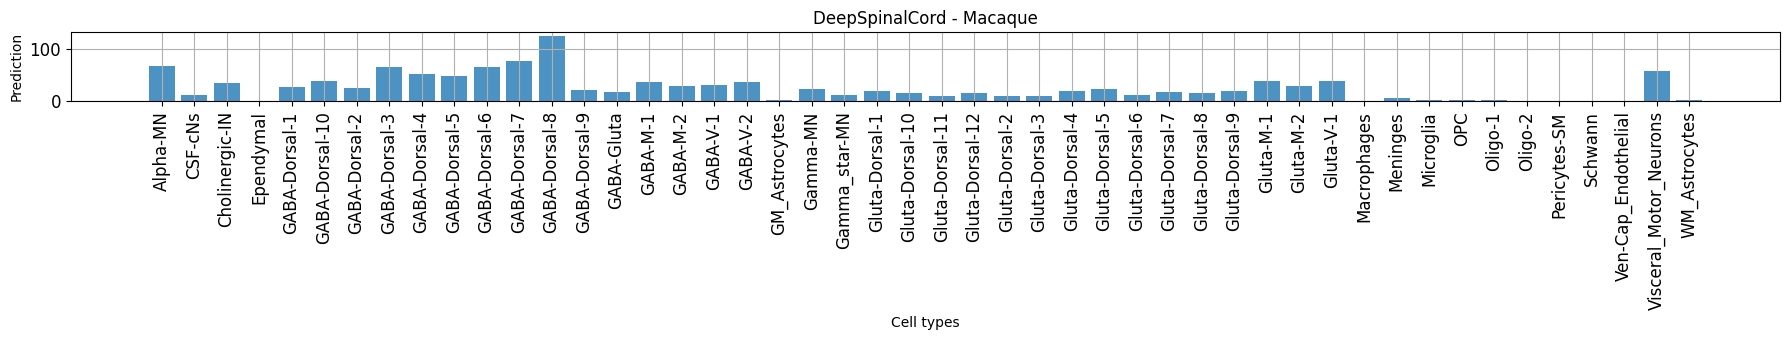

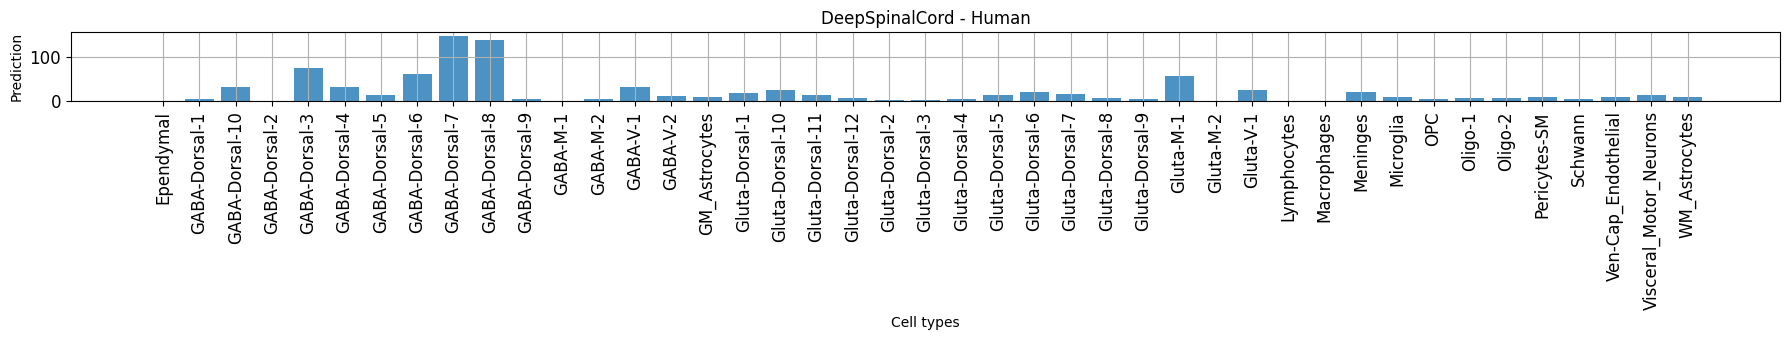

/home/niklas.kempynck/miniconda3/envs/crested_testing/lib/python3.10/site-packages/crested/pl/_utils.py:95: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


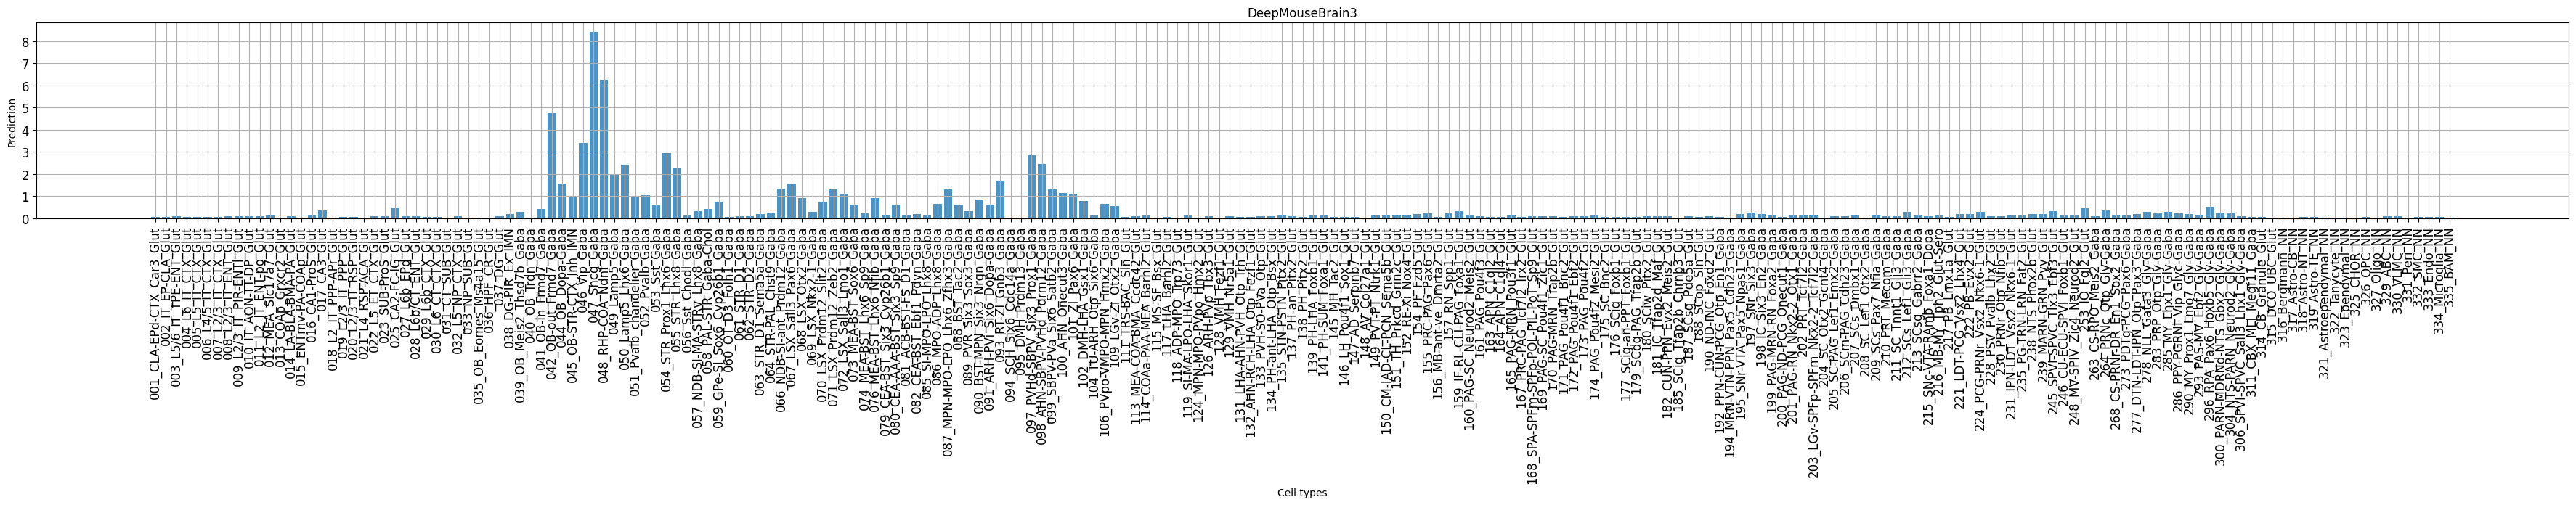

In [56]:
prediction_macaque = crested.tl.predict(seq, macaque_model)
prediction_mouse = crested.tl.predict(seq, mouse_model)
prediction_human = crested.tl.predict(seq, human_model)

prediction_wmb = crested.tl.predict(seq, model_wmb)

crested.pl.bar.prediction(prediction_mouse, classes=output_names_mouse, x_label_rotation=90, height=3.5, title='DeepSpinalCord - Mouse')
crested.pl.bar.prediction(prediction_macaque, classes=output_names_macaque, x_label_rotation=90, height=3.5, title='DeepSpinalCord - Macaque')
crested.pl.bar.prediction(prediction_human, classes=output_names_human, x_label_rotation=90, height=3.5, title='DeepSpinalCord - Human')
crested.pl.bar.prediction(prediction_wmb, classes=output_names_wmb, x_label_rotation=90, height=3.5, title='DeepMouseBrain3', width=45)

In [57]:

classes_of_interest = ["Alpha-MN","Gamma-MN", "Gamma_star-MN", "Visceral_Motor_Neurons"]
class_idx_mac = list(adata_macaque.obs_names.get_indexer(classes_of_interest))

#class_idx_mac = list(np.flip(np.argsort(prediction_macaque[0]))[:3])
regions_of_interest=[seq]
scores_mac, one_hot_encoded_sequences = crested.tl.contribution_scores(
    regions_of_interest,
    target_idx=class_idx_mac,
    model=macaque_model,
    method='integrated_grad'
)

class_idx_mou = list(adata_mouse.obs_names.get_indexer(classes_of_interest))
#class_idx_mou = list(np.flip(np.argsort(prediction_mouse[0]))[:3])

regions_of_interest=[seq]
scores_mou, one_hot_encoded_sequences = crested.tl.contribution_scores(
    regions_of_interest,
    target_idx=class_idx_mou,
    model=mouse_model,
    method='integrated_grad'
)

class_idx_hum = list(np.flip(np.argsort(prediction_human[0]))[:3])

regions_of_interest=[seq]
scores_hum, one_hot_encoded_sequences = crested.tl.contribution_scores(
    regions_of_interest,
    target_idx=class_idx_hum,
    model=human_model,
    method='integrated_grad'
)

2025-07-11T14:46:14.915303-0700 INFO Calculating contribution scores for 4 class(es) and 1 region(s).


Model: 100%|██████████| 1/1 [00:00<00:00,  2.80it/s]

2025-07-11T14:46:15.274939-0700 INFO Calculating contribution scores for 4 class(es) and 1 region(s).



Model: 100%|██████████| 1/1 [00:00<00:00,  3.15it/s]

2025-07-11T14:46:15.593963-0700 INFO Calculating contribution scores for 3 class(es) and 1 region(s).



Model: 100%|██████████| 1/1 [00:00<00:00,  4.19it/s]


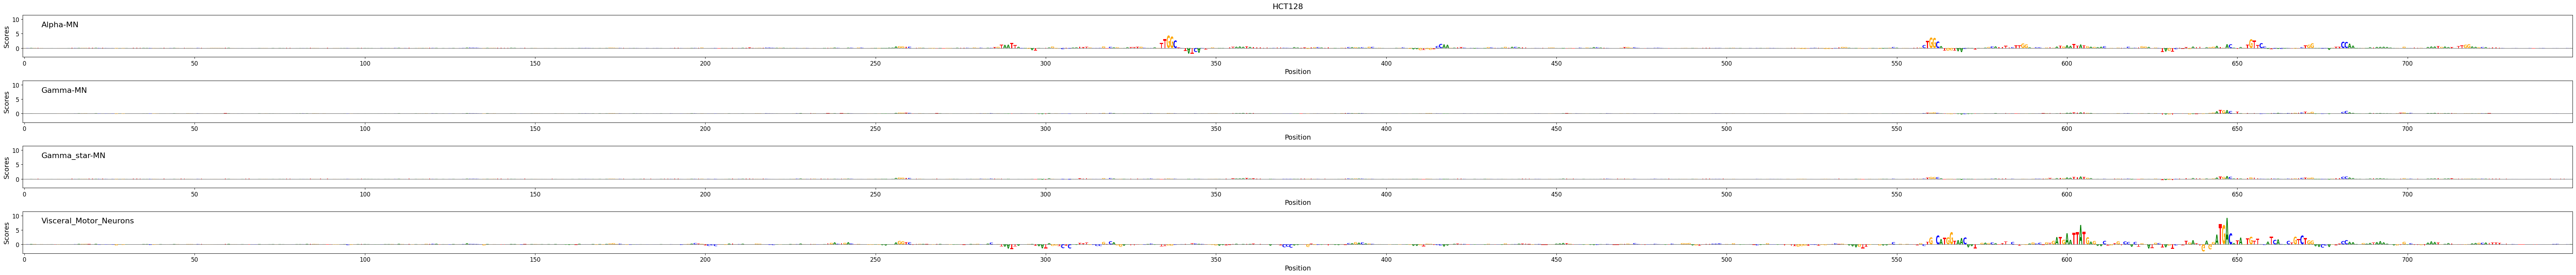

In [58]:
%matplotlib inline
crested.pl.patterns.contribution_scores(
    scores_mou,
    one_hot_encoded_sequences,
    sequence_labels=[""],
    class_labels=list(np.array(adata_mouse.obs_names)[class_idx_mou]),
    zoom_n_bases=len_,
    title=id_,
    height=8
)  # zoom in on the center 500bp

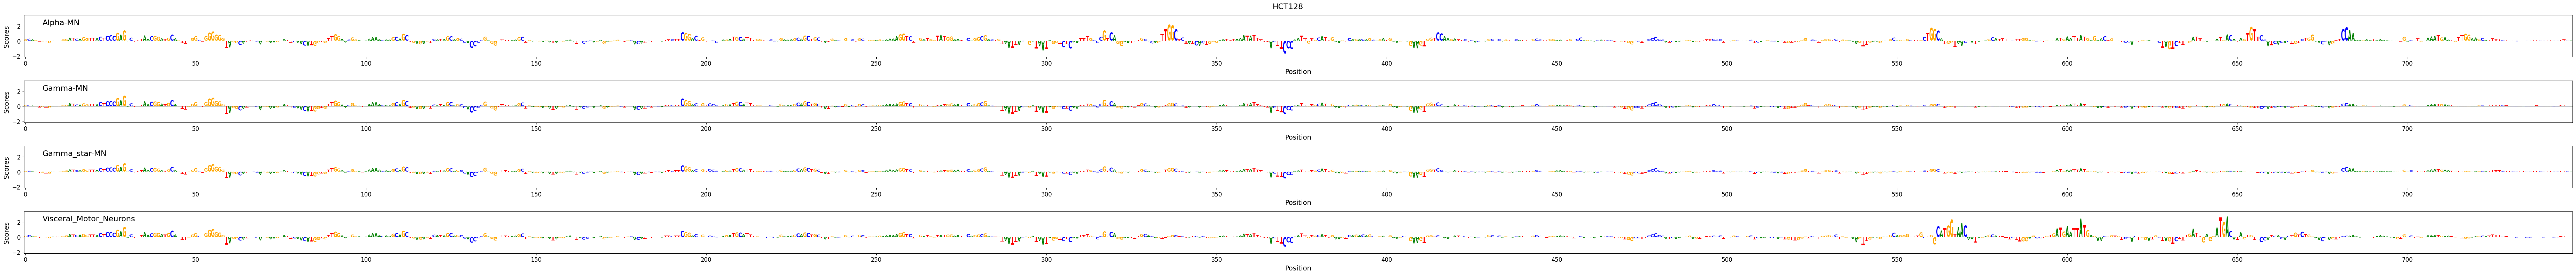

In [59]:
%matplotlib inline
crested.pl.patterns.contribution_scores(
    scores_mac,
    one_hot_encoded_sequences,
    sequence_labels=[""],
    class_labels=list(np.array(adata_macaque.obs_names)[class_idx_mac]),
    zoom_n_bases=len_,
    title=id_,
    height=8
)  # zoom in on the center 500bp

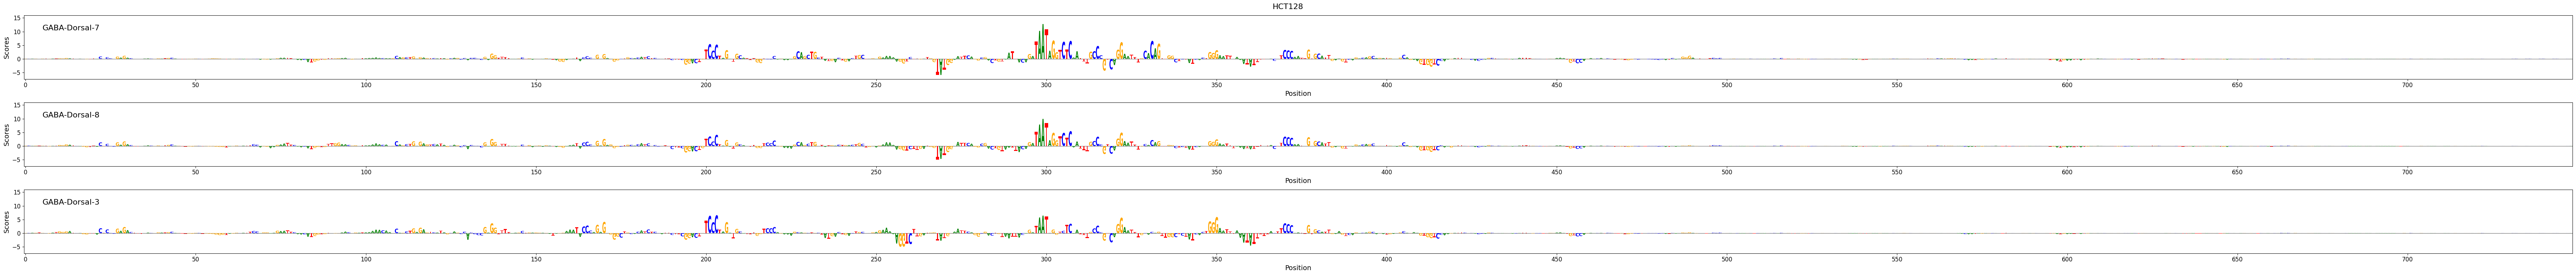

In [60]:
%matplotlib inline
crested.pl.patterns.contribution_scores(
    scores_hum,
    one_hot_encoded_sequences,
    sequence_labels=[""],
    class_labels=list(np.array(adata_human.obs_names)[class_idx_hum]),
    zoom_n_bases=len_,
    title=id_,
    height=8
)  # zoom in on the center 500bp

In [47]:
class_idx_wmb = list(np.flip(np.argsort(prediction_wmb[0]))[:3])

regions_of_interest=[seq]
scores_wmb, one_hot_encoded_sequences = crested.tl.contribution_scores(
    regions_of_interest,
    target_idx=class_idx_wmb,
    model=model_wmb,
    method='integrated_grad'
)

2025-07-11T13:24:31.499764-0700 INFO Calculating contribution scores for 3 class(es) and 1 region(s).


Model: 100%|██████████| 1/1 [00:00<00:00,  1.90it/s]


In [48]:
np.array(output_names_wmb)[class_idx_wmb]

array(['216_MB-MY_Tph2_Glut-Sero', '156_MB-ant-ve_Dmrta2_Glut',
       '133_PVH-SO-PVa_Otp_Glut'], dtype='<U38')

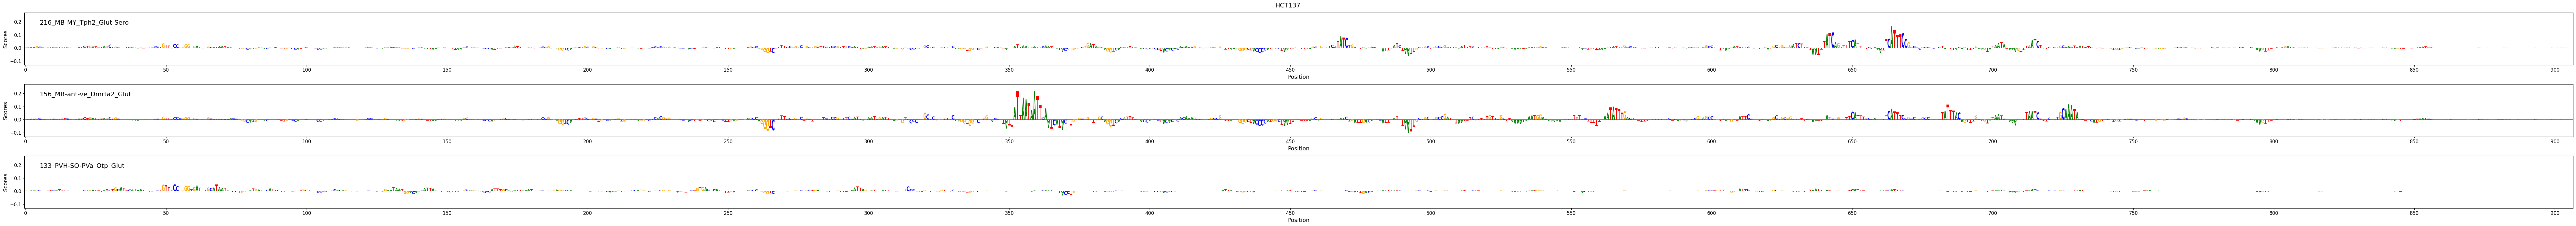

In [49]:
%matplotlib inline
crested.pl.patterns.contribution_scores(
    scores_wmb,
    one_hot_encoded_sequences,
    sequence_labels=[""],
    class_labels=list(np.array(output_names_wmb)[class_idx_wmb]),
    zoom_n_bases=len_,
    title=id_,
    height=8
)  # zoom in on the center 500bp